In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df= pd.read_csv("Game_dataset.csv")
df.head()

,UserID,Age,Gender,Country,Device,GameGenre,SessionCount,AverageSessionLength,SpendingSegment,InAppPurchaseAmount,FirstPurchaseDaysAfterInstall,PaymentMethod,LastPurchaseDate,TotalPlayTime,HighEngagementFlag,AgeGroup
0,c9889ab0-9cfc-4a75-acd9-5eab1df0015c,49,Male,Norway,Android,Battle Royale,9,12.83,Minnow,11.40,28,Apple Pay,19-03-2025,115.47,False,36-50
1,7c9e413c-ecca-45f2-a780-2826a07952a2,15,Male,Switzerland,iOS,Action RPG,11,19.39,Minnow,6.37,18,Debit Card,08-06-2025,213.29,False,<18
2,fd61e419-1a92-4f43-a8c7-135842ad328a,23,Male,China,Android,Fighting,9,8.87,Minnow,15.81,30,Apple Pay,02-06-2025,79.83,False,18-25
3,bdb7f6d1-ff9a-468c-afe7-43f32a94293e,31,Male,Mexico,Android,Racing,12,19.56,Minnow,13.49,9,Debit Card,01-04-2025,234.72,False,26-35
4,aa7eec14-4846-47b9-b879-9c98038cda04,37,Female,India,Android,Battle Royale,10,15.23,Minnow,10.86,15,Paypal,05-05-2025,152.30,False,36-50


In [8]:
# Total Players
total_players = df.shape[0]

In [9]:
# Paying Players
paying_players = df[df['InAppPurchaseAmount'] > 0].shape[0]

In [10]:
# Total Revenue
total_revenue = df['InAppPurchaseAmount'].sum()

In [13]:
# ARPU(Avg Revenue Per User) & ARPPU(Average Revenue Per Paying User)
arpu = total_revenue / total_players
arppu = total_revenue / paying_players

In [14]:
# Payer Conversion %
payer_conversion = (paying_players / total_players) * 100

print(f"Total Revenue: ${total_revenue:.2f}")
print(f"ARPU: ${arpu:.2f}")
print(f"ARPPU: ${arppu:.2f}")
print(f"Payer Conversion: {payer_conversion:.2f}%")

Total Revenue: $272862.81
ARPU: $99.84
ARPPU: $104.51
Payer Conversion: 95.54%


**Insights:**

1. Almost 96% of players are paying, which is very high — indicates a highly monetized user base.

2. ARPU (~$100) vs ARPPU (~$105) → most revenue comes from the majority of paying players, not just whales.

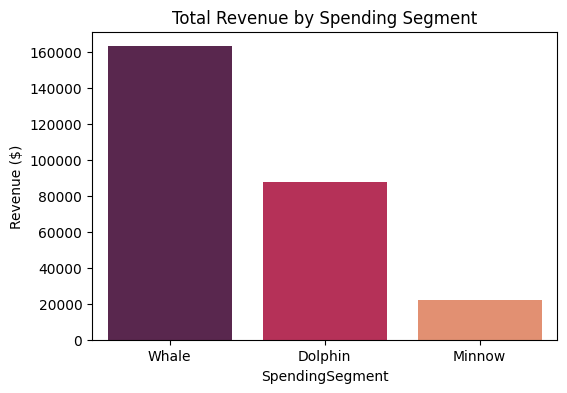

In [16]:
segment_revenue = df.groupby('SpendingSegment')['InAppPurchaseAmount'].sum().sort_values(ascending=False)

plt.figure(figsize=(6,4))
sns.barplot(x=segment_revenue.index, y=segment_revenue.values, palette='rocket',hue = segment_revenue.index, legend=False)
plt.title('Total Revenue by Spending Segment')
plt.ylabel('Revenue ($)')
plt.show()

**Insights:**

1. Whales contribute ~60% of revenue, even if they are a smaller portion of players

2. Dolphins (~32%) and Minnows (8%) still important — could incentivize Dolphins to upgrade via offers

 **Revenue by AgeGroup & Gender :**

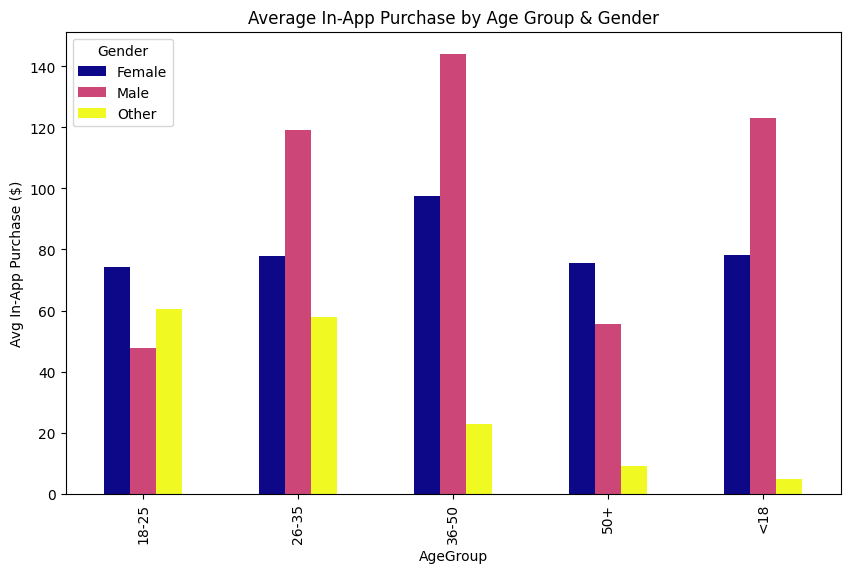

In [17]:
age_gender_revenue = df.groupby(['AgeGroup','Gender'])['InAppPurchaseAmount'].mean().unstack()

age_gender_revenue.plot(kind='bar', figsize=(10,6), colormap='plasma')
plt.title('Average In-App Purchase by Age Group & Gender')
plt.ylabel('Avg In-App Purchase ($)')
plt.show()

**Insights:**

1. Highest spenders: 36–50 Male (144.19) and 26–35 Male (119.16)

2. Females in 36–50 (97.62) also significant

3. “Other” segment has spikes in some age groups → potential niche targeting

4. Younger players (<18) spend less, as expected

**First Purchase Analysis :**

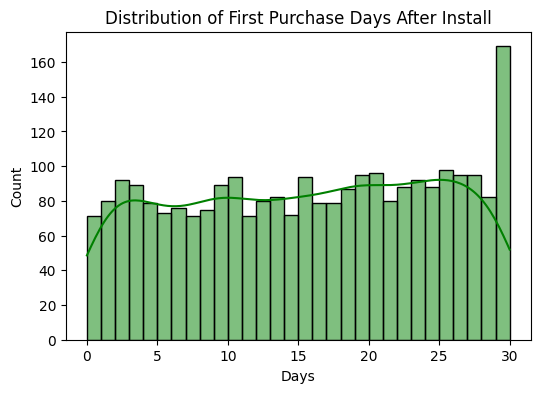

In [18]:
first_purchase = df[df['InAppPurchaseAmount'] > 0]['FirstPurchaseDaysAfterInstall']

plt.figure(figsize=(6,4))
sns.histplot(first_purchase, bins=30, kde=True, color='green')
plt.title('Distribution of First Purchase Days After Install')
plt.xlabel('Days')
plt.show()

In [19]:
avg_first_purchase = first_purchase.mean()
print(f"Average days to first purchase: {avg_first_purchase:.2f} days")

Average days to first purchase: 15.41 days


**Insights:**

1. Players tend to make first purchase within ~2 weeks

2. Opportunity: Launch early-game offers or starter packs in first 15 days to maximize revenue conversion

**Device & GameGenre Revenue :**

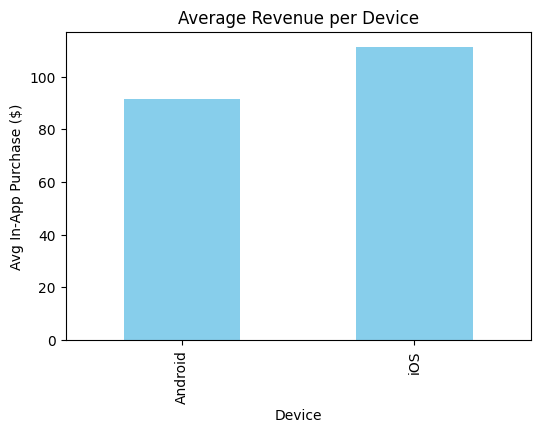

In [20]:
# Device
device_revenue = df.groupby('Device')['InAppPurchaseAmount'].mean()
device_revenue.plot(kind='bar', figsize=(6,4), color='skyblue')
plt.title('Average Revenue per Device')
plt.ylabel('Avg In-App Purchase ($)')
plt.show()

**Insights:**

1. iOS users spend more per player → could prioritize iOS monetization events

2. Android has higher player volume (if known) → consider volume vs revenue strategy

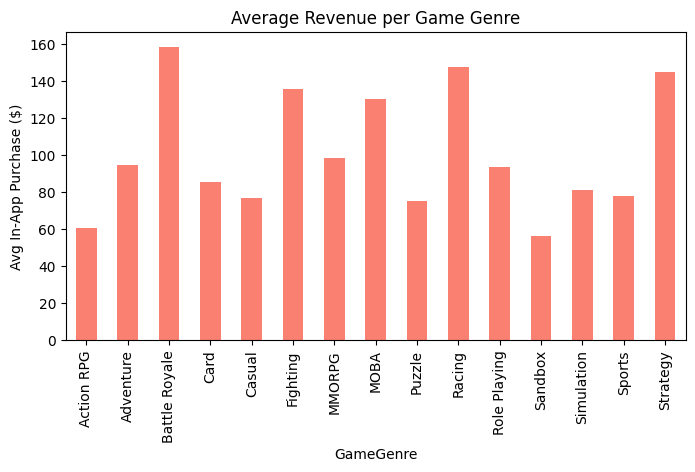

In [21]:
# GameGenre
genre_revenue = df.groupby('GameGenre')['InAppPurchaseAmount'].mean()
genre_revenue.plot(kind='bar', figsize=(8,4), color='salmon')
plt.title('Average Revenue per Game Genre')
plt.ylabel('Avg In-App Purchase ($)')
plt.show()

**Insights:**

1. Highest monetizing genres: Battle Royale, Racing, Strategy, Fighting, MOBA

2. Lowest monetizing genres: Sandbox, Action RPG, Puzzle → might need better in-game offers or engagement events